<center>
<h1 style='color: blue'>Supporting Information: Validation & Deep Dive Derivation</h1>

<h3>Spectral taxonomy for quartic systems: fundamental clock, parity, and continuum</h3>

    Teepanis Chachiyo <teepanisc@nu.ac.th>
    Department of Physics, Faculty of Science, Naresuan University,
    Phitsanulok 65000, Thailand.<br>
    
<h3 style='color: green'>Also available at https://github.com/teepanis/universal-spectral-structure/</h3>
</center><br>

Here we provide numerical validations and additional detailed derivations to help the readers understand thoroughly various aspects of the main text.


1. To see the validation, refer to Section 1.4
2. To deep dive the derivations, refer to Section 2.1
3. To inspect how the figures are plotted, refer to Section 3.1


<h2>Table of Contents</h2>

```
Description ............................................. Page

1.1 Complete Elliptic Integral                             2
1.2 Spectral Taxonomy Solutions                            3
1.3 Numerical Method Solutions                             5
1.4 Validations                                            6

2.1 Method: The Two Trigonometric Mappings                 9
2.2 Discussion: The Case Study
    2.2.1 Wick Rotation                                   10
    2.2.2 Quadratic Clock from the Taxonomy               12
    2.2.3 Wick Rotation: Clock, Parity, and Continuum     13
    2.2.4 Separatrix Solution of the Inverted Quadratic   14

3.1 Figure 1                                              15
3.2 Figure 2                                              17

4.1 References                                            22
```


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 2</h4></center>

### 1.1 Complete Elliptic Integral

The only special function needed for this framework is the standard complete elliptic integral of the first kind

$$
K(k) = \int_0^{\pi/2} \frac{d\theta}{\sqrt{1-k^2\sin^2 \theta}},
$$
which can be evaluated by a python module called `scipy` or an efficient numerical method in Ref.[1], $K \approx \frac{1}{n} \ln[(\frac{4}{\sqrt{1-k^2}})^n+b]$. However, numerical packages including `scipy` do not handle the case where $k > 1$ properly even though this is a well-defined property of the integral. Hence, we have to define this ourselves using analytical continuation. From Ref.[2],

$$
\begin{aligned}
 & \quad \text{Complementary } K && \Re[K(k)] \\ \hline
k < 1 & \qquad K(\sqrt{1-k^2}) && K(k) \\
k = 1 & \qquad K(0) = \pi/2 && K(1) \to \infty \\
k > 1 & \qquad K(\sqrt{1-1/k^2})/k && K(1/k)/k
\end{aligned}
$$


In [1]:
import scipy as sp
# note: ellipk takes the square of modulus

# real part of the complete elliptic integral of the first kind
def ReK(k):
    if k < 1: return sp.special.ellipk(k**2)
    if k ==1: return np.inf
    if k > 1: return sp.special.ellipk(1/k**2)/k
    
# complementary complete elliptic integral of the first kind
def Kc(k):
    if k < 1: return sp.special.ellipk(1-k**2)
    if k ==1: return np.pi/2
    if k > 1: return sp.special.ellipk(1-1/k**2)/k


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 3</h4></center>

### 1.2 Spectral Taxonomy Solutions

Below is the Python implementation that follows exactly as described in the Formalism, specifically Eq.(6)-(10). Once implemented, these solutions will be tested against a numerical method that is totally blind to the regimes/taxonomy.

$$
\begin{aligned}
& \text{Class 1:}\quad q(\tau) = \sum c_n \cos(n \Omega_0 \tau) + \frac{c_0}{2} \\
& \text{Class 2:}\quad q(\tau) = \sum s_n \sin(n \Omega_0 \tau)
\end{aligned}
$$

Below are the spectral parameters as defined in Eq.(9) and (10) in the main text.

In [2]:
import numpy as np
import scipy as sp

# exactly as defined in Eq.(6)-(10) in the spectral taxonomy
def spectral_params(sigma,gamma,epsilon):
    
    # squared-amplitudes
    A0 = -sigma 
    A1 = (-gamma + np.sqrt(gamma**2+2*sigma*epsilon))/sigma
    A2 = (-gamma - np.sqrt(gamma**2+2*sigma*epsilon))/sigma
    
    # spectral parameters
    zeta = np.sqrt(np.fabs(A0))
    if sigma==+1: OmegaL = zeta*np.sqrt(A1-A2)
    if sigma==-1: OmegaL = zeta*np.sqrt(A2) 
    k = zeta*np.sqrt(A1)/OmegaL
    T = 4*ReK(k)/OmegaL
    Omega0 = 2*np.pi/T
    kappa = Kc(k)

    return A0, A1, A2, zeta, OmegaL, k, T, Omega0, kappa


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 4</h4></center>

Once the spectral parameters are evaluated, the spectral organization and solutions are formed as described in Eq.(6), (7), and (8) as follows.

In [3]:
def spectral_taxonomy(sigma,gamma,epsilon, taui,tauf,dtau, maxN=40):
    
    # memory allocation
    tau = np.arange(taui,tauf,dtau)
    q = np.zeros(len(tau))
    c = np.zeros(maxN)
    s = np.zeros(maxN)
    
    # spectral parameters
    A0, A1, A2, zeta, OmegaL, k, T, Omega0, kappa = \
    spectral_params(sigma,gamma,epsilon)

    # spectral organization: kernel, parity, and DC-offset
    for n in range(1,maxN):
        if sigma==+1:
            if (k < 1 and n%2==1) or (k > 1 and n%2==0): 
                c[n] = 2*Omega0/zeta/np.cosh(kappa*n*Omega0/OmegaL)
        if sigma==-1: 
            if (k < 1 and n%2==1):
                s[n] = 2*Omega0/zeta/np.sinh(kappa*n*Omega0/OmegaL)

    # universal spectral solution
    if k != 1:
        
        if sigma==+1 and k > 1:
            c[0] = 2*Omega0/zeta
            q = q + c[0]/2

        for n in range(1,maxN):
            if sigma==+1: q = q + c[n]*np.cos(n*Omega0*tau)
            if sigma==-1: q = q + s[n]*np.sin(n*Omega0*tau)
            
    else:
        
        if sigma==+1:
            def integrand(Omega, tau):
                return 1/zeta/np.cosh(kappa*Omega/OmegaL)*np.cos(Omega*tau)
        if sigma==-1:
            def integrand(Omega, tau):
                return 1/zeta/np.sinh(kappa*Omega/OmegaL)*np.sin(Omega*tau)

        for i in range(len(tau)):
            I = sp.integrate.quad(integrand,0,40*OmegaL,args=(tau[i]),points=[0])
            q[i]= I[0]
            
    return tau, q


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 5</h4></center>

### 1.3 Numerical Method Solutions

This method is totally blind to regime classification. It only sees the governing equation, the physical parameters $(\sigma, \gamma)$, and the initial conditions, thereby establishing a truly blind test of the taxonomy.


In [4]:
# using euler-cromer method with very stable energy
def quartic_numer(sigma,gamma, q0,qdot0, taui,tauf,dtau):

    tau  = np.arange(taui,tauf,dtau)
    q    = np.zeros(len(tau))
    qdot = np.zeros(len(tau))
    
    #initial condition
    q[0]    = q0
    qdot[0] = qdot0
    
    for i in range(1,len(tau)):
        a = -2*sigma*q[i-1]**3 - 2*gamma*q[i-1]
        qdot[i] = qdot[i-1] + a*dtau
        q[i] = q[i-1] + qdot[i]*dtau
    
    return tau, q

<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 6</h4></center>

### 1.4 Validation: Oscillatory

Here we compare the solution $q(\tau)$ from the taxonomy to the numerical method for all bound, nontrivial motions. These include the shaded motion in Fig. 1, excluding the simple harmonic archetype $(\sigma,\gamma)=(0,+1)$.

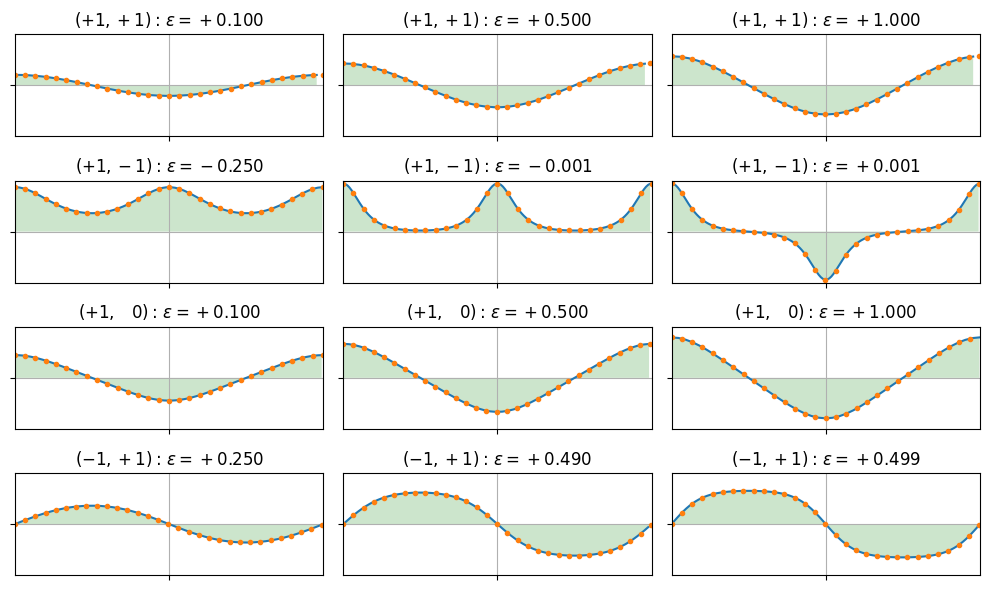

In [5]:
import matplotlib.pyplot as plt

def plot_solution(sigma,gamma,epsilon,ax,title):

    # spectral params
    A0, A1, A2, zeta, OmegaL, k, T, Omega0, kappa = \
    spectral_params(sigma,gamma,epsilon)
    
    # set time range
    taui=0
    tauf=T
    
    # set initial condition
    if sigma==+1: q0=np.sqrt(A1); qdot0=0
    if sigma==-1: q0=0; qdot0=np.sqrt(2*epsilon)
    
    tau, q = spectral_taxonomy(sigma,gamma,epsilon,taui,tauf,0.1)
    tau_numer, q_numer = quartic_numer(sigma,gamma,q0,qdot0,taui,tauf,0.001)

    ax.set_title(title)
    ax.set_xticks([T/2],[''])
    ax.set_yticks([0],[''])
    ax.grid()
    ax.set_ylim([-1.5,1.5])
    ax.set_xlim([0,T])
    ax.fill_between(tau,q,0*tau,facecolor='green',alpha=.2)
    ax.plot(tau,q)
    markskip = int(len(tau_numer)/30)
    ax.plot(tau_numer,q_numer,'.',markevery=markskip)

fig, ax = plt.subplots(4, 3, figsize=(10, 6))
plot_solution(+1,+1,+0.100,ax[0,0],'$(+1,+1): \, \epsilon=+0.100$')
plot_solution(+1,+1,+0.500,ax[0,1],'$(+1,+1): \, \epsilon=+0.500$')
plot_solution(+1,+1,+1.000,ax[0,2],'$(+1,+1): \, \epsilon=+1.000$')

plot_solution(+1,-1,-0.250,ax[1,0],'$(+1,-1): \, \epsilon=-0.250$')
plot_solution(+1,-1,-0.001,ax[1,1],'$(+1,-1): \, \epsilon=-0.001$')
plot_solution(+1,-1,+0.001,ax[1,2],'$(+1,-1): \, \epsilon=+0.001$')

plot_solution(+1,0,+0.100,ax[2,0],'$(+1,\;\;\;0): \, \epsilon=+0.100$')
plot_solution(+1,0,+0.500,ax[2,1],'$(+1,\;\;\;0): \, \epsilon=+0.500$')
plot_solution(+1,0,+1.000,ax[2,2],'$(+1,\;\;\;0): \, \epsilon=+1.000$')

plot_solution(-1,+1,+0.250,ax[3,0],'$(-1,+1): \, \epsilon=+0.250$')
plot_solution(-1,+1,+0.490,ax[3,1],'$(-1,+1): \, \epsilon=+0.490$')
plot_solution(-1,+1,+0.499,ax[3,2],'$(-1,+1): \, \epsilon=+0.499$')

plt.tight_layout()
plt.show()


Above shows all the bound, nontrivial motions for the four archetypes in Fig. 1. In each panel, the solid line is the spectral taxnonomy solutions while the dots are from numerical methods. The row corresponds to each archetype, shown in three representative energy values. In all cases, the clear agreement validate the taxonomy solutions presented in this work.

The shaded region visually illustrates the absent/present of the DC offset. Focus in the second row, depicting the archetype $(+1,-1)$. As described in the main text, the separatrix occurs at the energy $\epsilon = 0$. Furthermore, when the energy crosses the separatrix boundary, the DC offset disappears. This characteristics is clearly depicted in the second row. The DC offset is present on the left and the middle panel, but disappears entirely on the right one.

<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 8</h4></center>

### 1.4 Validation: Separatrix

The tests below validate the separatrix solutions in the taxonomy. It also shows that the separatrix is __not an arbitrary Fourier transform__, rather the exact continuum limit from the nearby osciallotry regimes. Specifically, the Fourier transform of the separatrix has the exact kernel as that of the oscillating regimes with the limit $\Omega_0 \to 0$. 

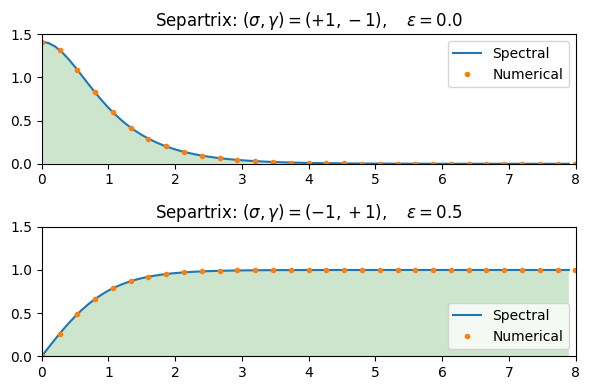

In [6]:
def plot_separatrix(sigma,gamma,epsilon,ax,title):

    # spectral params
    A0, A1, A2, zeta, OmegaL, k, T, Omega0, kappa = \
    spectral_params(sigma,gamma,epsilon)

    # set time range
    taui=0
    tauf=8

    # set initial condition
    if sigma==+1: q0=np.sqrt(A1); qdot0=0
    if sigma==-1: q0=0; qdot0=np.sqrt(2*epsilon)

    tau, q = spectral_taxonomy(sigma,gamma,epsilon,taui,tauf,0.1)
    tau_numer, q_numer = quartic_numer(sigma,gamma,q0,qdot0,taui,tauf,0.0001)

    ax.plot(tau,q,label='Spectral')
    markskip = int(len(tau_numer)/30)
    ax.plot(tau_numer, q_numer,'.',markevery=markskip,label='Numerical')
    ax.set_title(title)
    ax.fill_between(tau,q,0*tau,facecolor='green',alpha=.2)
    ax.legend()
    ax.set_xlim([taui,tauf])
    ax.set_ylim([0,1.5])

fig, ax = plt.subplots(2, 1, figsize=(6, 4))
plot_separatrix(+1,-1,0.0,ax[0],'Separtrix: $(\sigma,\gamma) = (+1,-1), \quad \epsilon = 0.0$')
plot_separatrix(-1,+1,0.5,ax[1],'Separtrix: $(\sigma,\gamma) = (-1,+1), \quad \epsilon = 0.5$')

plt.tight_layout()
plt.show()


As shown above, the spectral solutions which uses that exact kernel as that of nearby oscillatory reigmes are validated by the numerical solutions. 

<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 9</h4></center>

### 2.1 Method: The Two Trigometric Mappings

Recall in the Method that in Eq. (24), the quartic backbone motion can be written in an integral form:

$$
d\tau = \frac{\pm dq}{\sqrt{A_0 (q^2 - A_1)(q^2 - A_2)}}.
$$

The next step is to formulate a change of variable (mapping) $q \to \phi$ that transforms the quartic backbone into the standard definition of the elliptic integral:

$$
d\tau = \frac{1}{\Omega_L} \frac{d\phi}{\sqrt{1-k^2 \sin^2 \phi}}.
$$

It is then stated in the main text that because of the opposite sign of $A_0$, the two classes reguire different mappings as follows.

$$
\begin{aligned}
& \text{Class 1: } \quad A_0 = -1 \quad q = \sqrt{A_1} \cos \phi \\
& \text{Class 2: } \quad A_0 = +1 \quad q = \sqrt{A_1} \sin \phi 
\end{aligned}
$$

Here, we elaborate as to why the two maps are the algebraic necessity.

The shift in mapping is not a creative choice; it is forced by the algebraic signature of the potential in order to keep time ($\tau$) strictly real.

Look at the term $(q^2 - A_1)$ inside the square root of the equation of motion. 

- Class 1 ($A_0 < 0$):$\;$ We need to absorb the negative sign of $A_0$ to prevent an imaginary demoninator. If we use $q = \sqrt{A_1} \cos \phi$, the term evaluates to $A_1(\cos^2\phi - 1) = -A_1\sin^2 \phi$. The negative sign from the trigonometric identity perfectly cancels the negative sign of $A_0$. 
- Class 2 ($A_0 > 0$):$\;$ Since $A_0$ is already positive, if we used cosine, we would be stuck with a negative term under the square root. By using $q = \sqrt{A_1} \sin \phi$, the algebra naturally factors into the standard form $(1 - k^2\sin^2\phi)$ without generating an imaginary time step.


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 10</h4></center>

### 2.2 Discussion: The Case Study

#### 2.2.1 Wick Rotation

##### A. The Differential Eqution

Consider the $(0,+1)$ archetype where the potential $V(q) = +q^2$, the energy equation is:

$$
\left(\frac{dq}{d\tau}\right)^2 = 2\epsilon - 2q^2, \quad \epsilon > 0.
$$

Applying the Wick rotation $\tau \to i\tau$ means $d\tau \to i\,d\tau$. Squaring this pulls out a negative sign:

$$
\begin{aligned}
 -\left(\frac{dq}{d\tau}\right)^2 & = +2\epsilon - 2q^2, \\
 \left(\frac{dq}{d\tau}\right)^2 & =  -2\epsilon + 2q^2.
\end{aligned}
$$

To restore this to the standard energy form $\left(\frac{dq}{d\tau}\right)^2 = 2\epsilon_{\text{new}} - 2V_{\text{new}}(q)$, we define the mapped energy as $\epsilon \to -\epsilon$. This gives:

$$
\left(\frac{dq}{d\tau}\right)^2 = 2\epsilon + 2q^2.
$$

This is exactly the dynamics of a purely inverted parabolic potential $V(q) = -q^2$, perfectly matching the $(0, -1)$ archetype.

<br>

##### B. The Parity Preservation of the Solutions

Now we apply the joint substitution ($\tau \to i\tau$ and $\epsilon \to -\epsilon$) directly to the two harmonic solutions.

<span style='color: blue'>_Branch 1: The Cosine $\to$ Cosh Mapping:_</span> We start with the bound cosine solution:

$$
q(\tau) = \sqrt{\epsilon}\cos(\Omega_0 \tau)
$$

Substituting the Wick rotated variables:

$$
q(\tau) = \sqrt{-\epsilon}\cos(i \Omega_0 \tau).
$$

Using the identity $\cos(ix) = \cosh(x)$, this becomes:

$$
\boxed{ q(\tau) = \sqrt{-\epsilon}\cosh(\Omega_0 \tau), \quad \epsilon < 0.}
$$

The Physics: For this spatial trajectory to remain real, the term inside the square root must be positive. This mathematically strictly dictates that $\epsilon < 0$. It perfectly describes a particle that lacks the energy to cross the potential peak, starting from rest at $q_0 = \sqrt{-\epsilon}$ and accelerating outward.

<span style='color: blue'>_Branch 2: The Sine $\to$ Sinh Mapping:_</span> We start with the bound sine solution:

$$
q(\tau) = \sqrt{\epsilon}\sin(\Omega_0 \tau).
$$

Substituting the Wick rotated variables:

$$
q(\tau) = \sqrt{-\epsilon}\sin(i \Omega_0 \tau)
$$

Using the identity $\sin(ix) = i\sinh(x)$:

$$
q(\tau) = \sqrt{-\epsilon} \Big(i \sinh(\Omega_0 \tau)\Big)
$$

Because $i = \sqrt{-1}$, we can absorb the imaginary unit into the square root ($i \sqrt{-\epsilon} = \sqrt{+\epsilon}$):

$$
\boxed{ q(\tau) = \sqrt{+\epsilon}\sinh(\Omega_0 \tau), \quad \epsilon > 0.}
$$

The Physics: For this trajectory to be real, the energy constraint flips: we strictly require $\epsilon > 0$. This perfectly describes a particle starting at the origin ($q_0 = 0$) with a positive kinetic kick ($\dot{q}_0 = \sqrt{2\epsilon}$) that allows it to cross the potential peak.

##### Conclusion

The Wick rotation proves that the $(0,+1)$ and $(0,-1)$ archetypes are merely complex mirror images of the exact same underlying spectral structure.The two new solutions for the Unbound Archetype $(0, -1)$ become:

$$
\begin{aligned}
& q(\tau) = \sqrt{-\epsilon}\cosh(\Omega_0 \tau), &&  \quad (q_0, \dot{q}_0) = (\sqrt{-\epsilon}, 0), &  \quad  \epsilon < 0, \\
& q(\tau) = \sqrt{+\epsilon}\sinh(\Omega_0 \tau), &&  \quad (q_0, \dot{q}_0) = (0,\sqrt{+ 2\epsilon}), &  \quad \epsilon > 0.
\end{aligned}
$$

By absorbing the spatial inversion $i^2 = -1$ during the $\sin \to i\sinh$ transition, the math elegantly sorts the solutions into two distinct, physically real energy regimes: bounce ($\epsilon < 0$) and passing ($\epsilon > 0$).


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 12</h4></center>

#### 2.2.2 Quadratic Clock from the Taxonomy

In the quadratic potential, one can show that the fundamental frequency $\Omega_0 = \sqrt{2}$ arises naturally from the fundamental clock in the taxonomy by simply taking the limit $\sigma \to 0$. Therefore, the discussion suggests that the general expression of the fundamental clock

$$
\Omega_0 = \frac{2\pi}{T}, \quad T = \frac{4 \Re[K(k)]}{\Omega_L},
$$

may indeed transcend all potential archetypes, irrespective of trapped or runaway motions. To rigorously prove this conjecture, one needs to go beyond the inverted quardratic $V(q) = -q^2$ and shows that the mathematical expression holds true for __all unbound archetypes__ in the taxonomy.

Narrow our focus to the quadratic archetype $(\sigma,\gamma)=(0,+1)$. By taking the limit $\sigma \to 0$, we can see that the spectral parameters in Eq. (9) and (10) becomes:

$$
\begin{aligned}
\text{frequency scale } \Omega_L & \to \begin{cases}\text{Class 1: } (\sigma \to 0^+)\quad \sqrt{|A_0|(A_1 - A_2)} & = \sqrt{2}, \\ \text{Class 2: } (\sigma \to 0^-) \quad \sqrt{|A_0|A_2} & = \sqrt{2},  \end{cases} \\
\text{elliptic modulus } k & \to \sqrt{|A_0|A_1}/\Omega_L = 0, \\
\text{fundamental period } T & \to 2 \pi/\Omega_L, \\
\text{fundamental frequency } \Omega_0 & \to \Omega_L, \\
\text{envelope scale } \kappa & \to \infty.
\end{aligned}
$$

Therefore, $\Omega_0 = \Omega_L = \sqrt{2}$ arises from the limit $\sigma \to 0$ of the spectral taxonomy. Not only the $\Omega_0$, the form of the solutions which branches into two classes can also be derived from the taxonomy as well. In the limit $k \to 0$, we can use the asymptotic form of the complete elliptic integral of the first kind [Ref.1].

$$
\kappa = K'(0) \to \ln(\frac{4}{k}).
$$

For Class 1, the spectral coefficient become:

$$
\begin{aligned}
c_n & = \frac{2\Omega_0}{\sqrt{|A_0|}\cosh[\ln(\frac{4}{k}) n]}  = \frac{2 \Omega_0 \times 2}{ \sqrt{|A_0|} (\frac{4}{k})^n + \sqrt{|A_0|} (\frac{k}{4})^n}
\end{aligned}
$$

Applying $k = \sqrt{|A_0| A_1}/\Omega_L$, the denominator diverges to infinity because the prefactor $\sqrt{|A_0|}$ cannot keep up with $k^{-n}$ for $n > 1$. Therefore, $c_n = 0 \text{ for }  n > 1$. However, for $n = 1$, applying Eq. (5) leads to $c_1 = \sqrt{\epsilon}$. The solution for Class 1 elegantly collapses to:

$$
q(\tau) = \sqrt{\epsilon} \cos(\Omega_0 \tau).
$$

Similar logic can be applied to Class 2, which directly yields:

$$
q(\tau) = \sqrt{\epsilon} \sin(\Omega_0 \tau).
$$

In conclusion, the spectral taxonomy is formally applicable to all bound motions for $\sigma = \{+1, 0, -1 \}$, nontrivial or otherwise.

<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 13</h4></center>

#### 2.2.3 Wick Rotation: Clock, Parity, and Continuum 

Below, Fig. S1 shows that the Clock $(\Omega_0 = \sqrt{2})$, Parity, and the Continuum survive the Wick rotation.



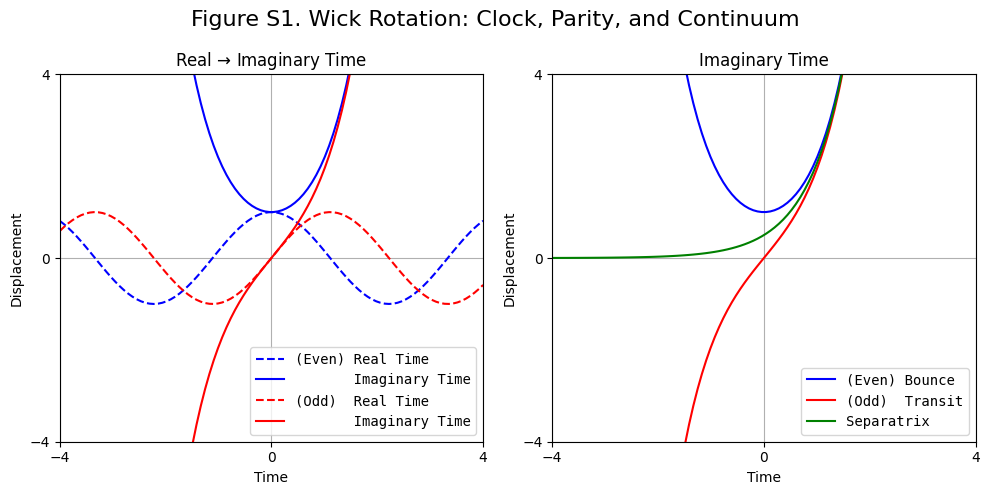

In [7]:
Omega0 = np.sqrt(2)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
tau = np.linspace(-4,4,100)
ax[0].plot(tau,np.cos(Omega0*tau),'b--',label='(Even) Real Time')
ax[0].plot(tau,np.cosh(Omega0*tau),'b-',label='       Imaginary Time')
ax[0].plot(tau,np.sin(Omega0*tau),'r--',label='(Odd)  Real Time')
ax[0].plot(tau,np.sinh(Omega0*tau),'r-',label='       Imaginary Time')

ax[1].plot(tau,np.cosh(Omega0*tau),'b-',label='(Even) Bounce')
ax[1].plot(tau,np.sinh(Omega0*tau),'r-',label='(Odd)  Transit')
ax[1].plot(tau,np.exp(Omega0*tau)/2,'g-',label='Separatrix')

ax[0].set_title('Real $\\to$ Imaginary Time')
ax[1].set_title('Imaginary Time')

for i in range(2):
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('Displacement')
    ax[i].set_ylim(-4,4)
    ax[i].set_xlim(-4,4)
    ax[i].set_yticks([-4,0,4]) 
    ax[i].set_xticks([-4,0,4])
    ax[i].grid()
    ax[i].legend(prop={"family": "monospace", "size": 10})

plt.suptitle('Figure S1. Wick Rotation: Clock, Parity, and Continuum',fontsize=16)
plt.tight_layout()
plt.show()

The two panels above are plotted at the same time scale. As evident from the graphs, all motions (i.e., bound and unbound) share the same temporal identity $\Omega_0 = \sqrt{2}$. That means the Clock survives the Wick rotation.

On the left panel, the Parity is also strictly preserved. That means Parity does not care if the motion is trapped or runaway; it only cares about the interaction with the origin.

On the right panel where there exists a separatrix in the imaginary time construct, the separatrix solution is exactly in the middle of the nearby regimes. This shows that the Continuum can be interpreted more deeply than just a Fourier statement in the bound motion. It is the absolute unification of dynamical regimes.

These graphs clearly suggest that the spectral triad: Clock, Parity, and Continuum could really be foundational.

<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 14</h4></center>

#### 2.2.4 Separatrix Solution of the Inverted Quadratic

Here we show that in the runaway motion of the inverted quadratic, the separatrix is the literal average of the bounce and transit regimes (up to a time shift):

$$
q_\text{sep}(\tau) = \frac{1}{2}q_\text{bounce}(\tau) + \frac{1}{2} q_\text{transit}(\tau),
$$

thereby validating the statement in the Discussion that the Continuum can be interpreted more deeply as the unification limit of dynamical regimes.

Recall that the separatrix occurs when the total energy $\epsilon = 0$. Energetically, this sits exactly on the boundary between the bounce (even parity) motion and the transit (odd parity) motion.

At the separatrix, one may naively assume that when $\epsilon = 0$, the particle starts at rest at the potential peak, and thus remains indefinitely at $q_0 = 0, \dot{q}_0 = 0$. This initial condition, however, obscures the dynamics of the separatrix motion and, more importantly, its relation to the adjacent dynamical regimes.

To see this, we draw an analogy to pendulum-like dynamics. In a nonlinear pendulum, the separatrix occurs when the energy $E$ is exactly equal to the potential maximum. One can naively set the initial condition such that the mass starts at rest at the peak, remaining indefinitely at the unstable point. However, an alternative initial condition allows the pendulum to start at the bottom with an initial kinetic kick just enough for it to reach the top. In this case, the separatrix solution takes the form of $\tanh[\cdots]$, thus revealing its dynamics and spectral fingerprints.

For the inverted quadratic separatrix, we start with its equation of motion and set $\epsilon = 0$:

$$
\left( \frac{dq}{d\tau} \right)^2 = 2 q^2.
$$

Considering the branch where the particle stays on the right side of the potential peak, the exact analytic solution is:

$$
q_\text{sep} = e^{\Omega_0 (\tau - \tau_0) } = C e^{\Omega_0 \tau}
$$

Crucially, we allow for a time shift $\tau_0$, which is absorbed into the prefactor $C$ of the exponential term. Because this time shift is a free parameter, we fix $C$ to be exactly half of the bounce and transit amplitudes, as follows.

As the energy $\epsilon$ approaches zero from both sides, the adjacent regimes are:

$$
\begin{aligned}
& \text{Bounce (even): } && q(\tau) = \sqrt{|\epsilon|} \cosh(\Omega_0 \tau) \\
& \text{Transit (odd): } && q(\tau) = \sqrt{|\epsilon|} \sinh(\Omega_0 \tau) \\
& \text{Separatrix: } && q(\tau) = C e^{\Omega_0 \tau}, \quad C = \sqrt{|\epsilon|}/2
\end{aligned}
$$

It is crucial to emphasize that setting $C = \sqrt{|\epsilon|}/2$ does not imply the separatrix possesses non-zero energy $\epsilon$. Rather, it means we parameterize the initial time shift as a function of $\epsilon$. In the limit where $C \to 0$, the separatrix solution has been shifted in time such that $\Omega_0 \tau_0 \to \infty$. This mathematically corresponds to tracking the asymptotic evolution of a particle that departed the unstable equilibrium infinitely far in the past.

From the three listed solutions above, it can be seen that the separatrix solution is the literal average of the two nearby regimes.

<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 15</h4></center>

### 3.1 Figure 1 Four combinations of irreducable quartic potential

Here we show precisely how the Fig. 1 in the main text is plotted. First, we define a function that plots a single panel.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_potential(sigma,gamma,ax,title):

    q = np.linspace(-1.75,1.75,100)
    V = sigma/2*q**4 + gamma*q**2

    # well region
    if (sigma==1 and gamma==1)      \
        or (sigma==1 and gamma==-1) \
        or (sigma==1 and gamma==0)  \
        or (sigma==0 and gamma==1): 
        ax.fill_between(q,V,0*q+2,facecolor='green',alpha=.2,
                        label='potential well')
        if gamma==1:
            ax.plot([0,0],[0,2],'--',color='red')
        if gamma==-1:
            ax.plot([0,0],[-.5,2],'--',color='red')
        if gamma==0:
            ax.plot([0,0],[0,2],'--',color='red')
    if sigma==-1 and gamma==1:
        qq = np.linspace(-1,1)
        VV = sigma/2*qq**4 + gamma*qq**2
        ax.fill_between(qq,VV,0*qq+.5,facecolor='green',alpha=.2)
        ax.plot([0,0],[0,.5],'--',color='red')

    # plot potential
    ax.plot([-2,2],[0,0],'k')
    ax.plot(q,V,'-',color='blue',label='$V(q)$')
    ax.set_ylim(-1,1)
    ax.set_xlim(-1.5,1.5)

    # tick
    if sigma==0 and gamma==1:
        ax.set_yticks([-.5,0,.5],
                      ['$-\\frac{1}{2}$','0','$+\\frac{1}{2}$'])
    else:
        ax.set_yticks([-.5,0,.5],['','',''])
    if sigma==0 and gamma==1:
        ax.set_xticks([-1,-.5,0,.5,1],['-1','','0','','+1'])
    else:
        ax.set_xticks([-1,-.5,0,.5,1],['','','','',''])
        ax.tick_params(left=False, bottom=False)

    if sigma==0 and gamma==1:
        ax.set_xlabel('q')
        ax.legend()

    ax.set_title(title)
    ax.grid()    
    ax.spines['top'].set_edgecolor('gray')
    ax.spines['bottom'].set_edgecolor('gray')
    ax.spines['left'].set_edgecolor('gray')
    ax.spines['right'].set_edgecolor('gray')


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 16</h4></center>

Then we call the function multiple times, varying $\sigma,\gamma$ and title. The graph is optionally saved to PDF format and included in the main text.

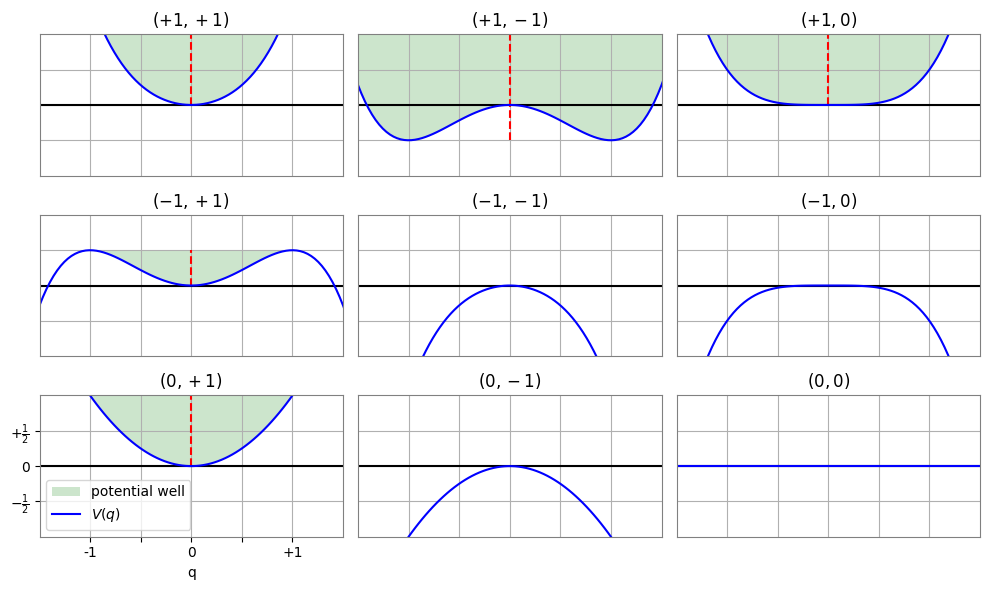

In [9]:
fig, ax = plt.subplots(3, 3, figsize=(10, 6))
plot_potential(+1,+1,ax[0,0],'$(+1,+1)$')
plot_potential(+1,-1,ax[0,1],'$(+1,-1)$')
plot_potential(+1, 0,ax[0,2],'$(+1, 0)$')

plot_potential(-1,+1,ax[1,0],'$(-1,+1)$')
plot_potential(-1,-1,ax[1,1],'$(-1,-1)$')
plot_potential(-1, 0,ax[1,2],'$(-1, 0)$')

plot_potential( 0,+1,ax[2,0],'$( 0,+1)$')
plot_potential( 0,-1,ax[2,1],'$( 0,-1)$')
plot_potential( 0, 0,ax[2,2],'$( 0, 0)$')

plt.tight_layout()
#plt.savefig('fig_potential.pdf')
plt.show()


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 17</h4></center>

### 3.2 Figure 2 Spacecraft Rotation

First we define a numerical method the solve for the velocities of all three principal axes.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy as sp

# scaled euler equation
def euler_cromer(y10, y20, y30, zi, zf, dz):

    z = np.arange(zi,zf,dz)
    h1 = np.zeros(len(z))
    h2 = np.zeros(len(z))
    h3 = np.zeros(len(z))
    y1 = np.zeros(len(z))
    y2 = np.zeros(len(z))
    y3 = np.zeros(len(z))

    # initial condition
    y1[0] = y10
    y2[0] = y20
    y3[0] = y30

    # euler-cromer simulation
    for i in range(1,len(z)):
        y1[i] = y1[i-1] - dz*y2[i-1]*y3[i-1]
        h1[i] = h1[i-1] + dz*y1[i]

        y2[i] = y2[i-1] + dz*y3[i-1]*y1[i-1]
        h2[i] = h2[i-1] + dz*y2[i]

        y3[i] = y3[i-1] - dz*y1[i-1]*y2[i-1]
        h3[i] = h3[i-1] + dz*y3[i]

    return z, y1, y2, y3


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 18</h4></center>

Here we define the spectral solution in real space as in Appendix B.

In [11]:
def uss_dynamics(c4,c2,E):

    A1 = (-c2 + np.sqrt(c2**2+4*c4*E))/(2*c4)
    A2 = (-c2 - np.sqrt(c2**2+4*c4*E))/(2*c4)
    
    if c4>0:
        OmegaL = np.sqrt(A1-A2)
    if c4<0:
        OmegaL = np.sqrt(A2)
    k = np.sqrt(A1)/OmegaL
    
    if k < 1:
        T = 4*sp.special.ellipk(k**2)/OmegaL
        kappa = sp.special.ellipk(1-k**2)
    if k == 1:
        T = np.inf
        kappa = np.pi/2
    if k > 1:
        T = 4*sp.special.ellipk(1/k**2)/k/OmegaL
        kappa = sp.special.ellipk(1-1/k**2)/k
    Omega0 = 2*np.pi/T
    
    return OmegaL, k, T, Omega0, kappa

def uss_x(t,c4,c2,E):

    OmegaL, k, T, Omega0, kappa = uss_dynamics(c4,c2,E)
    x = np.zeros(len(t))
    Omega = np.arange(0,40,1)*Omega0
    Coef = np.zeros(len(Omega))
    if c4 > 0 and k > 1:
        x = x + Omega0
        # Be careful !!!, by definition the DC term is coef_0/2
        Coef[0] = 2*Omega0
    
    for n in range(1,40,1):
        cn = 2*Omega0/np.cosh(kappa*n*Omega0/OmegaL)
        sn = 2*Omega0/np.sinh(kappa*n*Omega0/OmegaL)
        if c4 > 0:
            if (k < 1 and n%2==1) or (k > 1 and n%2==0):
                x = x + cn*np.cos(n*Omega0*t)
                Coef[n] = cn
        if c4 < 0:
            if (k < 1 and n%2==1):
                x = x + sn*np.sin(n*Omega0*t)
                Coef[n] = sn

    return x, Omega, Coef


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 19</h4></center>

Here we define the plotting function for the upper panels.

In [12]:
def plot_y(id,y10,y20,y30,ax):


    C1 = y20**2 + y10**2
    C3 = y20**2 + y30**2
    
    Cmin = np.min([C1,C3])
    Cmax = np.max([C1,C3])
    
    # fundmamental clock 
    T = 4*sp.special.ellipk(Cmin/Cmax)/np.sqrt(Cmax)
    if T==np.inf: T = 20.
    
    t, y1, y2, y3 = euler_cromer(y10,y20,y30, 0.,T,0.001)
    tu = np.linspace(0,T,30)
    
    # analytical y1
    c4 = 1/2
    c2 = (C3-2*C1)/2
    E = 1/2*C1*(C3-C1)
    y1_uss, _, _ = uss_x(tu,c4,c2,E)
    
    # analytical y2
    c4 = -1/2
    c2 = (C1+C3)/2
    E = 1/2*C1*C3
    y2_uss,_,_ = uss_x(tu,c4,c2,E)
    
    # analytical y3
    c4 = 1/2
    c2 = (C1-2*C3)/2
    E = 1/2*C3*(C1-C3)
    y3_uss,_,_ = uss_x(tu,c4,c2,E)
    
    ax.plot(tu,y1_uss,'.',color='#FF7777')
    ax.plot(tu,y2_uss,'.g')
    ax.plot(tu,y3_uss,'.',color='#7777FF')
    
    ax.plot(t,y1,'-',label='Axis 1',color='#FF7777')
    ax.plot(t,y2,'-g',label='Axis 2')
    ax.plot(t,y3,'-',label='Axis 3',color='#7777FF')

    ax.plot([T/2,T/2],[-2,2],'-k')
    ax.plot([0,T],[0,0],'-k')

    ax.set_ylim([-1.2,1.2])
    ax.set_xlim([0,T])
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(True)

    ax.spines['top'].set_edgecolor('gray')
    ax.spines['bottom'].set_edgecolor('gray')
    ax.spines['left'].set_edgecolor('gray')
    ax.spines['right'].set_edgecolor('gray')

    if id==1:
        ax.set_xticks([0,4,8])
        ax.set_xlabel('Time')
        ax.set_ylabel('Angular velocity')
        ax.yaxis.set_visible(True)
    if id==2: ax.set_xticks([0,8,16])
    if id==3: ax.set_xticks([0,16,32])


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 20</h4></center>

Below is for the lower panels, the spectral combs plot.

In [13]:
def plot_spectrum(id,y10,y20,y30,ax):

    C1 = y20**2 + y10**2
    C3 = y20**2 + y30**2

    t=np.linspace(0,10,10)

    #  y1 spectrum
    c4 = 1/2
    c2 = (C3-2*C1)/2
    E = 1/2*C1*(C3-C1)
    _,Omega,y1_coef = uss_x(t,c4,c2,E)

    #  y2 spectrum
    c4 = -1/2
    c2 = (C1+C3)/2
    E = 1/2*C1*C3
    _,Omega,y2_coef = uss_x(t,c4,c2,E)

    # y3 spectrum
    c4 = 1/2
    c2 = (C1-2*C3)/2
    E = 1/2*C3*(C1-C3)
    _,Omega,y3_coef = uss_x(t,c4,c2,E)

    if id==1:
        label1='Axis 1'
        label2='Axis 2'
        label3='Axis 3'
    else:
        label1=''
        label2=''
        label3=''

    if id==3:
        OmegaK = np.linspace(0.001,4,1000)
        ax.plot(OmegaK,2*Omega[1]/np.sinh(np.pi/2*OmegaK),'--',
                label='$\\frac{ \, \Delta\Omega}{\sinh(\cdots)}$')
        ax.plot(OmegaK,2*Omega[1]/np.cosh(np.pi/2*OmegaK),'-.',
                label='$\\frac{ \, \Delta\Omega}{\cosh(\cdots)}$')

    ax.bar(Omega,y1_coef,width=Omega[1]/1.5,color='#FFAAAA',label=label1)
    ax.plot(Omega,y2_coef,'o',color='green',fillstyle='none',markersize=8, label=label2)
    ax.bar(Omega,y3_coef,width=Omega[1]/1.5,color='#AAAAFF',label=label3)

    ax.set_yscale('log')
    ax.set_xlim([0,4])
    ax.set_ylim([1e-3,1e+1])
    if id==1 or id==3:
        ax.legend()
    if id==1:
        ax.set_xlabel('Frequency')
        ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='auto', numticks=12))
        ax.set_ylabel('Spectral weight')

# Chachiyo, T. (2025). Simple and accurate complete elliptic integrals for 
# the full range of modulus. Computer Physics Communications, 109931. 
# https://doi.org/10.1016/j.cpc.2025.109931
def invK(K):
    #n = (np.log(4) - np.log(np.pi))/(np.pi/2 - np.log(4))
    #b = np.exp(n*np.pi/2) - 4**n
    # -- pre-computed for speed ---
    n = 1.3092785997521463
    b = 1.678061276031407

    # avoid numerical divide-by-zero
    if K==np.pi/2: return 0

    return np.sqrt(1-16/(np.exp(n*K)-b)**(2/n))


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 21</h4></center>

Finally, this is the main plot for Figure 2.

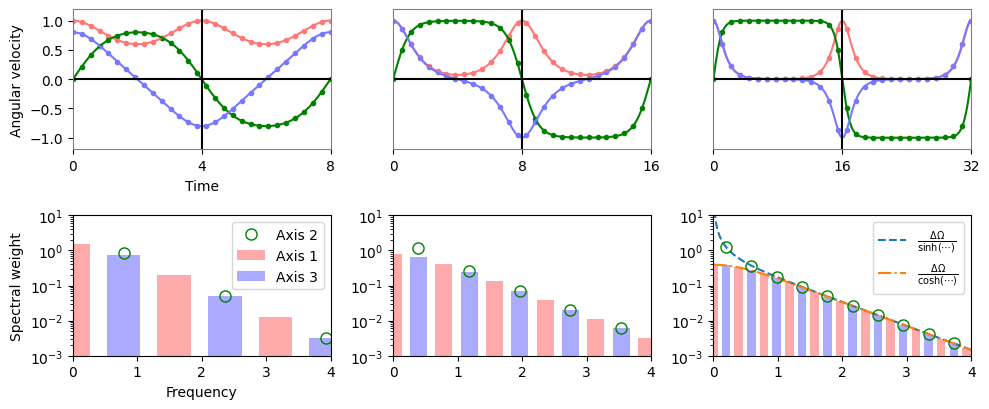

In [14]:
fig, ax = plt.subplots(2, 3, figsize=(10, 4.2))
k1 = invK(8/4)
k2 = invK(16/4)
k3 = invK(32/4)
plot_y(1, 1,0,k1, ax[0,0])
plot_y(2, 1,0,k2, ax[0,1])
plot_y(3, 1,0,k3, ax[0,2])
plot_spectrum(1,1,0,k1,ax[1,0])
plot_spectrum(2,1,0,k2,ax[1,1])
plot_spectrum(3,1,0,k3,ax[1,2])
plt.tight_layout()
#plt.savefig('fig_spacecraft.pdf')
plt.show()


<div style="page-break-before: always; break-before: page;"></div>
<center><h4>Page 22</h4></center>

### 4.1 References

1. Chachiyo, T. (2026). Simple and accurate complete elliptic integrals for the full range of modulus. Computer Physics Communications, 319, 109931. https://doi.org/10.1016/j.cpc.2025.109931
2. Chachiyo, T. (2026). Universal spectral structure in pendulum-like systems, URL https://arxiv.org/abs/2504.16816, ArXiv:2504.16816.